# Temporal Exercise Detection Demo

Quick demo of window-based temporal modeling for exercise detection.

## What's New:
- **Window-based**: 30-frame sliding windows instead of full videos
- **Two-stage**: GNN extracts spatial features → LSTM learns temporal patterns
- **Real-time ready**: Process 1-second chunks

In [1]:
# Add parent directory to path to import from training folder
import sys
sys.path.append('../training')

from train import TemporalExerciseTrainer
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
sns.set_style('whitegrid')

c:\Users\User\miniconda3\envs\exerdetect\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup and Load Data

In [2]:
# Your dataset path (already has processed CSV)
DATASET_PATH = r"C:\Users\User\.cache\kagglehub\datasets\data\exercise-videos\real-time-exercise-recognition-dataset\versions\1.0.0\training-data"
# Configuration
WINDOW_SIZE = 30  # 30 frames = 1 second at 30fps
STRIDE = 15       # 50% overlap
EPOCHS = 50
trainer = TemporalExerciseTrainer(DATASET_PATH)

## 2. Create Temporal Dataset

This converts your videos into sliding windows.

In [3]:
# Create windowed dataset
dataset, exercise_to_label = trainer.prepare_data(window_size=WINDOW_SIZE, stride=STRIDE)

print(f"\nDataset Info:")
print(f"  Exercises: {list(exercise_to_label.keys())}")
print(f"  Total windows: {len(dataset)}")

=== Temporal Exercise Recognition Training ===

Step 1: Extracting pose features with MediaPipe...
Processing dataset videos...
Processing barbell biceps curl...


  barbell biceps curl videos:   0%|          | 0/29 [00:00<?, ?it/s]c:\Users\User\miniconda3\envs\exerdetect\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
  barbell biceps curl videos: 100%|██████████| 29/29 [01:13<00:00,  2.52s/it]


Processing hammer curl...


  hammer curl videos: 100%|██████████| 12/12 [00:39<00:00,  3.29s/it]


Processing push-up...


...

Processing shoulder press...


  shoulder press videos: 100%|██████████| 22/22 [01:34<00:00,  4.28s/it]


Processing squat...


  squat videos: 100%|██████████| 23/23 [01:36<00:00,  4.21s/it]


Dataset processed: 25382 frames from 116 videos
Exercise mapping: {'barbell biceps curl': 0, 'hammer curl': 1, 'push-up': 2, 'shoulder press': 3, 'squat': 4}
Features loaded: 25382 frames
Exercises: ['barbell biceps curl', 'hammer curl', 'push-up', 'shoulder press', 'squat']

Step 2: Creating temporal window dataset...
Created 1535 windows from 116 videos
Window size: 30 frames, Stride: 15 frames

Dataset Info:
  Exercises: ['barbell biceps curl', 'hammer curl', 'push-up', 'shoulder press', 'squat']
  Total windows: 1535


## 3. Split Data

In [4]:
train_loader, test_loader = trainer.split_dataset(dataset)

Train windows: 1228
Test windows: 307


## 4. Train Model

**Architecture:**
```
30 frames → GNN (each frame) → 30 embeddings → LSTM → Classification
```


Step 3: Initializing Temporal GNN+LSTM model...
Model parameters: 265,797
Training on: cpu

Step 4: Training model...


Epoch 1/50: 100%|██████████| 77/77 [00:12<00:00,  6.01it/s, loss=1.4262, acc=42.02%]


Epoch 1/50: Loss: 1.3735, Accuracy: 0.4202


Epoch 2/50: 100%|██████████| 77/77 [00:12<00:00,  6.08it/s, loss=1.6534, acc=44.71%]


Epoch 2/50: Loss: 1.2565, Accuracy: 0.4471


...

Epoch 49/50: Loss: 0.7679, Accuracy: 0.7052


Epoch 50/50: 100%|██████████| 77/77 [00:17<00:00,  4.49it/s, loss=0.4397, acc=71.66%]


Epoch 50/50: Loss: 0.7376, Accuracy: 0.7166

Step 5: Evaluating model...


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.76it/s]



=== RESULTS ===
Test Accuracy: 0.7003 (70.03%)

Classification Report:
                     precision    recall  f1-score   support

barbell biceps curl       0.51      0.84      0.64        45
        hammer curl       0.53      0.29      0.38        31
            push-up       0.75      0.94      0.83        64
     shoulder press       0.79      0.78      0.79        92
              squat       0.80      0.48      0.60        75

           accuracy                           0.70       307
          macro avg       0.68      0.67      0.65       307
       weighted avg       0.72      0.70      0.69       307



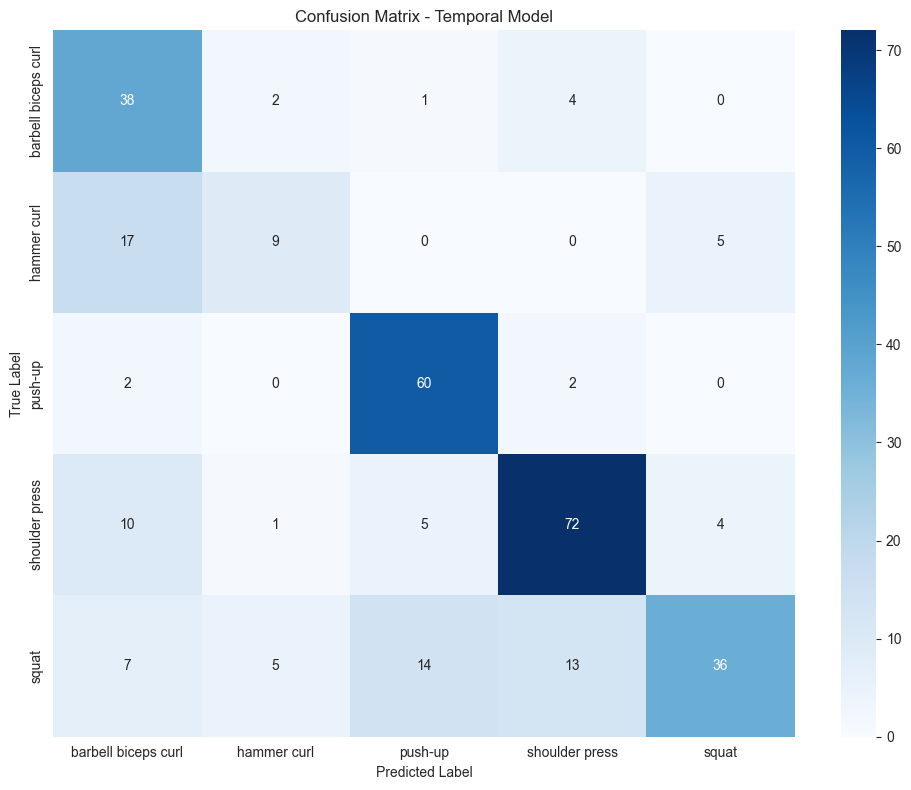

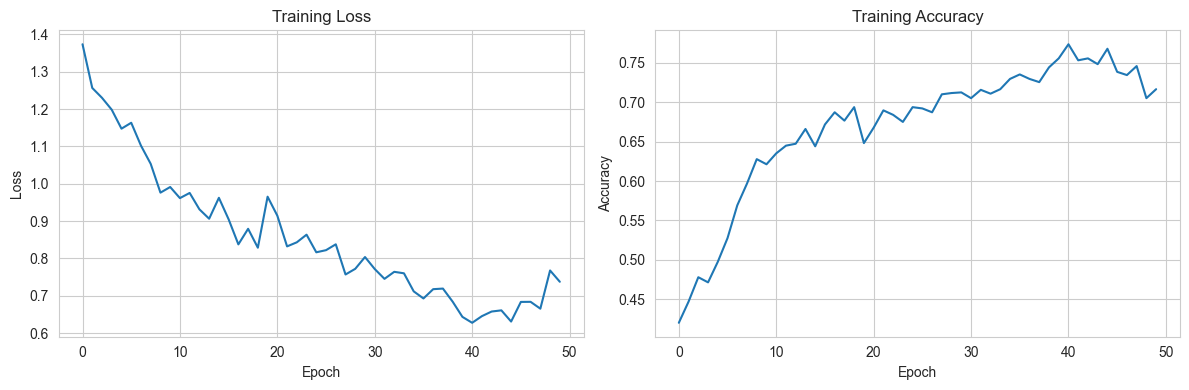


Model saved to C:\Users\User\.cache\kagglehub\datasets\data\exercise-videos\real-time-exercise-recognition-dataset\versions\1.0.0\training-data\temporal_model_best.pth
Training complete! Achieved 70.03% accuracy

✅ Training Complete!
Final Test Accuracy: 70.03%


In [5]:
model, exercise_mapping, accuracy = trainer.train(
    train_loader, 
    test_loader, 
    exercise_to_label,
    epochs=EPOCHS
)

print(f"\n✅ Training Complete!")
print(f"Final Test Accuracy: {accuracy*100:.2f}%")